<a href="https://colab.research.google.com/github/DeepthiManthapuram/Celebal_Excellence_Internship/blob/main/week5_Deepthi.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 📘 Deep Learning Text Generation Learning Project
## Text Generation using **Vanilla RNN, LSTM, and GRU**

This notebook is built for **students and beginners** to understand how sequence models learn:
- grammar
- sentence flow
- contextual dependencies
- next-word prediction
- text generation

🎯 **Goal:** Compare **Simple RNN vs LSTM vs GRU** on the same text corpus and understand why gated architectures perform better.

# 🧠 Problem Statement
Design and implement a DL model capable of learning the underlying structure, grammar, and contextual dependencies of a given text corpus to generate coherent and meaningful text sequences using:

1. **Vanilla RNN**
2. **LSTM**
3. **GRU**

Then compare:
- training loss
- generated text quality
- memory handling
- long-term dependency learning

In [41]:
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, LSTM, GRU, Dense
import numpy as np
import matplotlib.pyplot as plt
print("TensorFlow:", tf.__version__)

TensorFlow: 2.20.0


# 📥 Load Text Corpus
We use a **small built-in sample corpus** so students can run this quickly.
You can later replace it with:
- Shakespeare text
- song lyrics
- chatbot data
- story paragraphs
- custom PDF extracted text

In [42]:
corpus = '''
deep learning is transforming artificial intelligence
recurrent neural networks are useful for sequential data
lstm helps remember long term dependencies
gru is faster and simpler than lstm
text generation models predict the next word
deep learning models can generate meaningful sentences
'''
print(corpus)


deep learning is transforming artificial intelligence
recurrent neural networks are useful for sequential data
lstm helps remember long term dependencies
gru is faster and simpler than lstm
text generation models predict the next word
deep learning models can generate meaningful sentences



# 🔤 Tokenization & Sequence Creation
We convert text into integer tokens and create **n-gram style sequences**
for next-word prediction.

In [43]:
tokenizer = Tokenizer()
tokenizer.fit_on_texts([corpus])

total_words = len(tokenizer.word_index) + 1
print("Vocabulary size:", total_words)

input_sequences = []
for line in corpus.split('\n'):
    token_list = tokenizer.texts_to_sequences([line])[0]
    for i in range(1, len(token_list)):
        n_gram_seq = token_list[:i+1]
        input_sequences.append(n_gram_seq)

max_len = max(len(seq) for seq in input_sequences)
input_sequences = pad_sequences(input_sequences, maxlen=max_len, padding='pre')

X = input_sequences[:, :-1]
y = input_sequences[:, -1]

print("X shape:", X.shape)
print("y shape:", y.shape)

Vocabulary size: 37
X shape: (35, 7)
y shape: (35,)


# 🧠 Model 1: Vanilla RNN
This is the baseline sequential model.
It struggles with long-term dependencies because of vanishing gradients.

In [44]:
rnn_model = Sequential([
    Embedding(total_words, 32, input_length=max_len-1),
    SimpleRNN(64),
    Dense(total_words, activation='softmax')
])

rnn_model.compile(loss='sparse_categorical_crossentropy',
                  optimizer='adam',
                  metrics=['accuracy'])

rnn_history = rnn_model.fit(X, y, epochs=100, verbose=0)
print("Vanilla RNN training completed")

Vanilla RNN training completed


# 🔒 Model 2: LSTM
LSTM uses **input, forget, and output gates**
to preserve long-term memory.

In [45]:
lstm_model = Sequential([
    Embedding(total_words, 32, input_length=max_len-1),
    LSTM(64),
    Dense(total_words, activation='softmax')
])

lstm_model.compile(loss='sparse_categorical_crossentropy',
                   optimizer='adam',
                   metrics=['accuracy'])

lstm_history = lstm_model.fit(X, y, epochs=100, verbose=0)
print("LSTM training completed")

LSTM training completed


# ⚡ Model 3: GRU
GRU uses **reset + update gates**.
It is computationally faster than LSTM and often gives similar results.

In [46]:
gru_model = Sequential([
    Embedding(total_words, 32, input_length=max_len-1),
    GRU(64),
    Dense(total_words, activation='softmax')
])

gru_model.compile(loss='sparse_categorical_crossentropy',
                  optimizer='adam',
                  metrics=['accuracy'])

gru_history = gru_model.fit(X, y, epochs=100, verbose=0)
print("GRU training completed")

GRU training completed


## 📉 Compare Training Loss

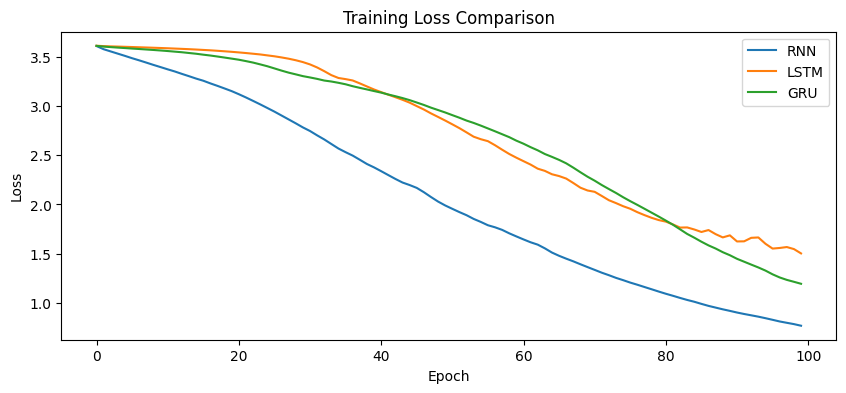

In [47]:
plt.figure(figsize=(10,4))
plt.plot(rnn_history.history['loss'], label='RNN')
plt.plot(lstm_history.history['loss'], label='LSTM')
plt.plot(gru_history.history['loss'], label='GRU')
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss Comparison")
plt.legend()
plt.show()

# ✍️ Text Generation Function
This function predicts the next word repeatedly to generate a sentence.

In [48]:
def generate_text(model, seed_text, next_words=5):
    for _ in range(next_words):
        token_list = tokenizer.texts_to_sequences([seed_text])[0]
        token_list = pad_sequences([token_list], maxlen=max_len-1, padding='pre')
        predicted = np.argmax(model.predict(token_list, verbose=0), axis=-1)[0]

        output_word = ""
        for word, index in tokenizer.word_index.items():
            if index == predicted:
                output_word = word
                break
        seed_text += " " + output_word
    return seed_text

## 🧪 Generate Text Samples

In [49]:
print("RNN :", generate_text(rnn_model, "deep learning", 5))
print("LSTM:", generate_text(lstm_model, "deep learning", 5))
print("GRU :", generate_text(gru_model, "deep learning", 5))

RNN : deep learning models can generate meaningful sentences
LSTM: deep learning is is artificial intelligence than
GRU : deep learning models can generate meaningful sentences


# 📚 Student Learning Tasks
### ✅ Beginner Tasks
1. Replace corpus with your own paragraph
2. Increase embedding dimension
3. Increase epochs to 200
4. Change hidden units 64 → 128
5. Generate 10 words instead of 5

# ✅ Conclusion
- **Vanilla RNN** learns short patterns but struggles with memory
- **LSTM** captures long-range grammar dependencies better
- **GRU** gives similar performance with fewer gates and faster training
- This notebook helps students understand **sequence modeling mathematically and practically**

# **Begginer Tasks**

In [50]:
corpus2 = '''
The dataset was collected and loaded into the system.
The data was preprocessed by handling missing values and scaling the features.
The dataset was divided into training and testing sets.
A neural network model was created with an input layer, hidden layers, and an output layer.
Suitable activation functions were applied to the hidden and output layers.
The model was compiled using an optimizer and an appropriate loss function.
The neural network was trained using the training dataset for a fixed number of epochs.
During training, the weights were updated using the backpropagation algorithm.
The trained model was tested using the testing dataset.
The model's performance was evaluated using metrics such as accuracy and loss.
'''
print(corpus2)


The dataset was collected and loaded into the system.
The data was preprocessed by handling missing values and scaling the features.
The dataset was divided into training and testing sets.
A neural network model was created with an input layer, hidden layers, and an output layer.
Suitable activation functions were applied to the hidden and output layers.
The model was compiled using an optimizer and an appropriate loss function.
The neural network was trained using the training dataset for a fixed number of epochs.
During training, the weights were updated using the backpropagation algorithm.
The trained model was tested using the testing dataset.
The model's performance was evaluated using metrics such as accuracy and loss.



## Tokenize the Text

In [51]:
from tensorflow.keras.preprocessing.text import Tokenizer

tokenizer = Tokenizer()
tokenizer.fit_on_texts([corpus2])

print("Vocabulary Dictionary:")
print(tokenizer.word_index)

Vocabulary Dictionary:
{'the': 1, 'was': 2, 'and': 3, 'using': 4, 'dataset': 5, 'an': 6, 'training': 7, 'model': 8, 'into': 9, 'testing': 10, 'a': 11, 'neural': 12, 'network': 13, 'layer': 14, 'hidden': 15, 'layers': 16, 'output': 17, 'were': 18, 'loss': 19, 'trained': 20, 'collected': 21, 'loaded': 22, 'system': 23, 'data': 24, 'preprocessed': 25, 'by': 26, 'handling': 27, 'missing': 28, 'values': 29, 'scaling': 30, 'features': 31, 'divided': 32, 'sets': 33, 'created': 34, 'with': 35, 'input': 36, 'suitable': 37, 'activation': 38, 'functions': 39, 'applied': 40, 'to': 41, 'compiled': 42, 'optimizer': 43, 'appropriate': 44, 'function': 45, 'for': 46, 'fixed': 47, 'number': 48, 'of': 49, 'epochs': 50, 'during': 51, 'weights': 52, 'updated': 53, 'backpropagation': 54, 'algorithm': 55, 'tested': 56, "model's": 57, 'performance': 58, 'evaluated': 59, 'metrics': 60, 'such': 61, 'as': 62, 'accuracy': 63}


# Print Vocabulary Size

In [52]:
total_words = len(tokenizer.word_index) + 1

print("Total Vocabulary Size:", total_words)

Total Vocabulary Size: 64


# Create Input Sequences

In [53]:
from tensorflow.keras.preprocessing.sequence import pad_sequences

input_sequences = []

for line in corpus2.split('\n'):
    token_list = tokenizer.texts_to_sequences([line])[0]

    for i in range(1, len(token_list)):
        n_gram_seq = token_list[:i+1]
        input_sequences.append(n_gram_seq)

print("Input Sequences:")

for seq in input_sequences:
    print(seq)

Input Sequences:
[1, 5]
[1, 5, 2]
[1, 5, 2, 21]
[1, 5, 2, 21, 3]
[1, 5, 2, 21, 3, 22]
[1, 5, 2, 21, 3, 22, 9]
[1, 5, 2, 21, 3, 22, 9, 1]
[1, 5, 2, 21, 3, 22, 9, 1, 23]
[1, 24]
[1, 24, 2]
[1, 24, 2, 25]
[1, 24, 2, 25, 26]
[1, 24, 2, 25, 26, 27]
[1, 24, 2, 25, 26, 27, 28]
[1, 24, 2, 25, 26, 27, 28, 29]
[1, 24, 2, 25, 26, 27, 28, 29, 3]
[1, 24, 2, 25, 26, 27, 28, 29, 3, 30]
[1, 24, 2, 25, 26, 27, 28, 29, 3, 30, 1]
[1, 24, 2, 25, 26, 27, 28, 29, 3, 30, 1, 31]
[1, 5]
[1, 5, 2]
[1, 5, 2, 32]
[1, 5, 2, 32, 9]
[1, 5, 2, 32, 9, 7]
[1, 5, 2, 32, 9, 7, 3]
[1, 5, 2, 32, 9, 7, 3, 10]
[1, 5, 2, 32, 9, 7, 3, 10, 33]
[11, 12]
[11, 12, 13]
[11, 12, 13, 8]
[11, 12, 13, 8, 2]
[11, 12, 13, 8, 2, 34]
[11, 12, 13, 8, 2, 34, 35]
[11, 12, 13, 8, 2, 34, 35, 6]
[11, 12, 13, 8, 2, 34, 35, 6, 36]
[11, 12, 13, 8, 2, 34, 35, 6, 36, 14]
[11, 12, 13, 8, 2, 34, 35, 6, 36, 14, 15]
[11, 12, 13, 8, 2, 34, 35, 6, 36, 14, 15, 16]
[11, 12, 13, 8, 2, 34, 35, 6, 36, 14, 15, 16, 3]
[11, 12, 13, 8, 2, 34, 35, 6, 36, 14, 15, 16,

# Convert Tokens Back to Words

In [54]:
reverse_word_map = {v:k for k,v in tokenizer.word_index.items()}

print("Token to Word Mapping:")

for i in range(1, total_words):
    print(i, "->", reverse_word_map[i])

Token to Word Mapping:
1 -> the
2 -> was
3 -> and
4 -> using
5 -> dataset
6 -> an
7 -> training
8 -> model
9 -> into
10 -> testing
11 -> a
12 -> neural
13 -> network
14 -> layer
15 -> hidden
16 -> layers
17 -> output
18 -> were
19 -> loss
20 -> trained
21 -> collected
22 -> loaded
23 -> system
24 -> data
25 -> preprocessed
26 -> by
27 -> handling
28 -> missing
29 -> values
30 -> scaling
31 -> features
32 -> divided
33 -> sets
34 -> created
35 -> with
36 -> input
37 -> suitable
38 -> activation
39 -> functions
40 -> applied
41 -> to
42 -> compiled
43 -> optimizer
44 -> appropriate
45 -> function
46 -> for
47 -> fixed
48 -> number
49 -> of
50 -> epochs
51 -> during
52 -> weights
53 -> updated
54 -> backpropagation
55 -> algorithm
56 -> tested
57 -> model's
58 -> performance
59 -> evaluated
60 -> metrics
61 -> such
62 -> as
63 -> accuracy


# Pad the Sequences

In [55]:
max_len = max(len(seq) for seq in input_sequences)

input_sequences = pad_sequences(
    input_sequences,
    maxlen=max_len,
    padding='pre'
)

print("Maximum Sequence Length:", max_len)

Maximum Sequence Length: 16


# Prepare Features and Labels

In [56]:
X = input_sequences[:, :-1]
y = input_sequences[:, -1]

print("X Shape:", X.shape)
print("y Shape:", y.shape)

X Shape: (105, 15)
y Shape: (105,)


# Train the LSTM Model

In [57]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense

lstm_model = Sequential([
    Embedding(total_words, 64, input_length=max_len-1),
    LSTM(128),
    Dense(total_words, activation='softmax')
])

lstm_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

lstm_model.fit(X, y, epochs=200, verbose=0)

print("Training Completed")

Training Completed


# Generate 10 Words

In [58]:
import numpy as np

def generate_text(model, seed_text, next_words=10):

    for _ in range(next_words):

        token_list = tokenizer.texts_to_sequences([seed_text])[0]

        token_list = pad_sequences(
            [token_list],
            maxlen=max_len-1,
            padding='pre'
        )

        predicted = np.argmax(
            model.predict(token_list, verbose=0),
            axis=-1
        )[0]

        output_word = ""

        for word, index in tokenizer.word_index.items():
            if index == predicted:
                output_word = word
                break

        seed_text += " " + output_word

    return seed_text

# Generate Text

In [59]:
print(generate_text(lstm_model, "the dataset", 10))

the dataset was divided into training and testing sets a fixed number


# Try Another Seed

In [60]:
print(generate_text(lstm_model, "the model", 10))

the model was compiled using an optimizer and an appropriate loss function


In [61]:
print(generate_text(lstm_model, "the model", 10))

the model was compiled using an optimizer and an appropriate loss function
